# H&M Transaction Data: Product Recommendations 02
## Neural Net Model

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

import os
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# data processing classes
from src.customer_features import CustomerFeatureEngineer
from src.product_features import ProductFeatureEngineer
from src.recommendation_training import RecommendationTrainingBuilder


## Load Processed Data

In [19]:
# Load data from parquet
data_path = Path("../data")
processed_data_path = data_path / 'processed' / 'product_recommendation'

with open(processed_data_path / 'X_train_base.pkl', 'rb') as f:
    X_train = pickle.load(f)
with open(processed_data_path / 'y_train_base.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open(processed_data_path / 'X_val_base.pkl', 'rb') as f:
    X_val = pickle.load(f)
with open(processed_data_path / 'y_val_base.pkl', 'rb') as f:
    y_val = pickle.load(f)
with open(processed_data_path / 'X_test_base.pkl', 'rb') as f:
    X_test = pickle.load(f)
with open(processed_data_path / 'y_test_base.pkl', 'rb') as f:
    y_test = pickle.load(f)

print(f"{X_train.shape=}")
print(f"{y_train.shape=}")
print(f"{X_val.shape=}")
print(f"{y_val.shape=}")
print(f"{X_test.shape=}")
print(f"{y_test.shape=}")

X_train.shape=(238936, 43)
y_train.shape=(238936,)
X_val.shape=(440082, 43)
y_val.shape=(440082,)
X_test.shape=(326736, 43)
y_test.shape=(326736,)


In [3]:
# Check what data was loaded
print(f"X_train type: {type(X_train)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_train memory: {X_train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nData types:")
print(X_train.dtypes)

X_train type: <class 'pandas.core.frame.DataFrame'>
X_train shape: (168986, 43)
X_train memory: 55.44 MB

Data types:
garment_Outdoor                            int64
garment_Special Offers                     int64
is_new_customer                          float64
garment_Accessories                        int64
sales_last_7_days                        float64
days_since_last_purchase                 float64
Active                                   float64
club_member_status_NOT_ACTIVE_MEMBER     float64
days_since_first_sale                    float64
age                                      float64
sales_last_30_days                       float64
garment_Trousers                           int64
garment_Trousers Denim                     int64
FN                                       float64
garment_Jersey Basic                       int64
garment_Under-, Nightwear                  int64
avg_days_between_purchases               float64
garment_Dresses/Skirts girls               int64


## Feature Engineering and Scaling

### Log transform financial features

In [4]:
cols_to_log = ['avg_price', 'max_price', 'total_spent', 'min_price', 'num_purchases', 'sales_last_7_days', 'sales_last_30_days']

for price_feature in cols_to_log:
    X_train[f"log_{price_feature}"] = np.log1p(X_train[price_feature])
    X_train.drop(columns=[price_feature], inplace=True)
    X_val[f"log_{price_feature}"] = np.log1p(X_val[price_feature])
    X_val.drop(columns=[price_feature], inplace=True)
    X_test[f"log_{price_feature}"] = np.log1p(X_test[price_feature])
    X_test.drop(columns=[price_feature], inplace=True)
    

### Standard Scaler

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"X_train before scaling - mean: {X_train.mean().mean():.2f}, std: {X_train.std().mean():.2f}")
print(f"X_train after scaling - mean: {X_train_scaled.mean():.2f}, std: {X_train_scaled.std():.2f}")

X_train before scaling - mean: 1.67, std: 1.03
X_train after scaling - mean: 0.00, std: 1.00


## Description of Data

### Correlation Matrix

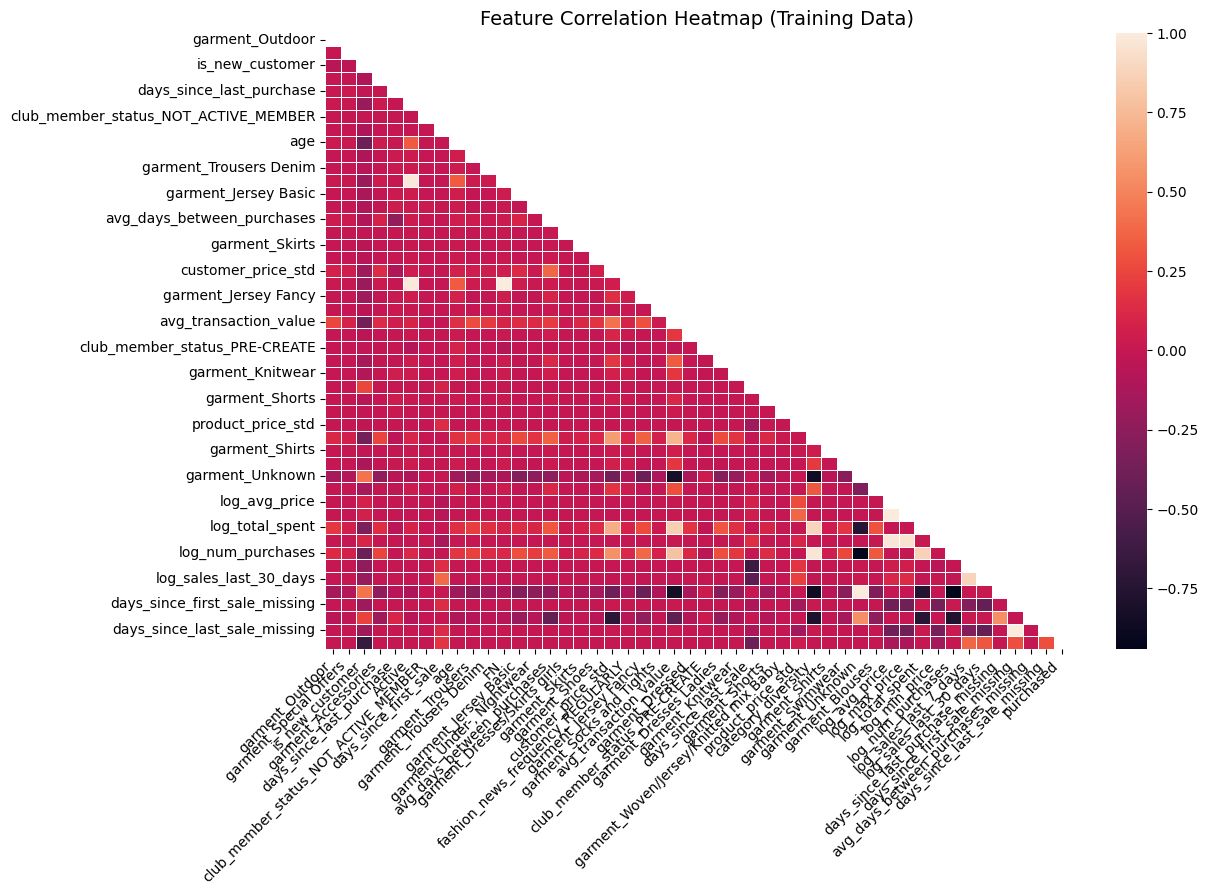

In [7]:
corr = pd.concat([X_train, y_train], axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
ax = sns.heatmap(corr,mask=mask,annot=False, linewidths=.5)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.title('Feature Correlation Heatmap (Training Data)', fontsize=14)
plt.show()

### Distribution of price

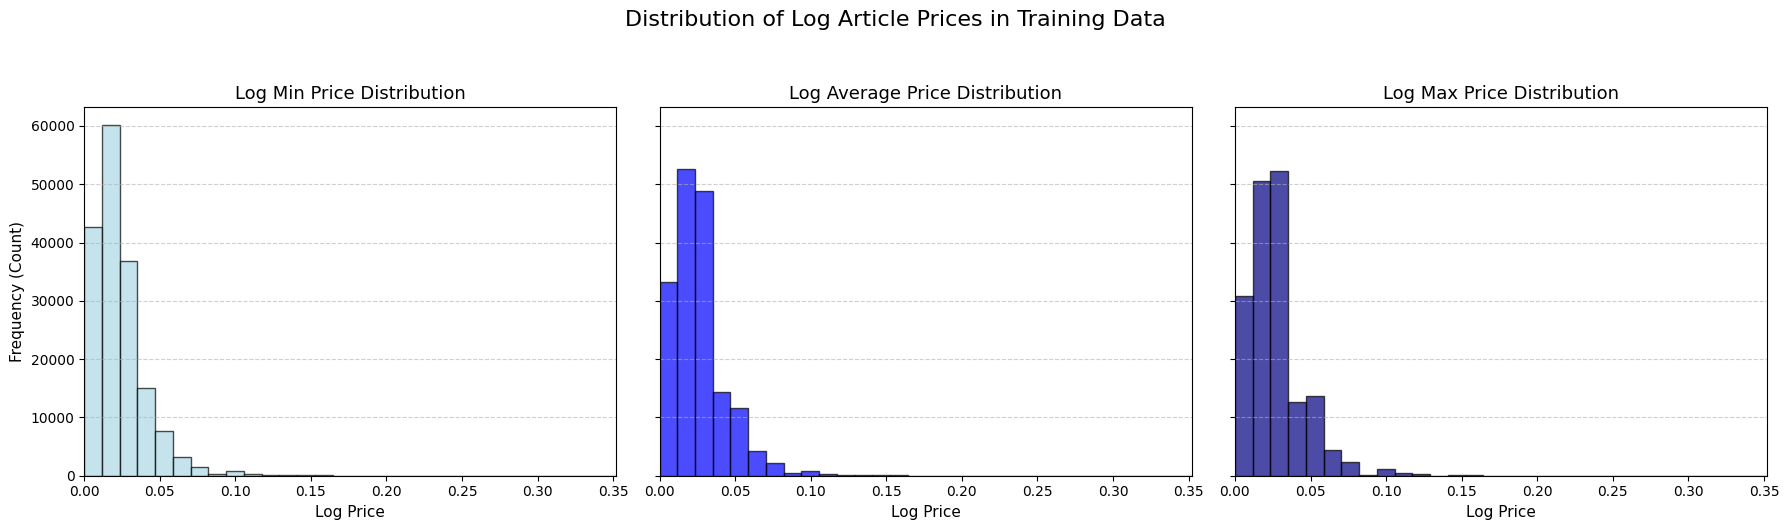

In [8]:
log_price_cols = ['log_min_price', 'log_avg_price', 'log_max_price']
X_train_prices = X_train[log_price_cols].copy()

x_min = X_train_prices.min().min()
x_max = X_train_prices.max().max()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
titles = ['Log Min Price Distribution', 'Log Average Price Distribution', 'Log Max Price Distribution']
colors = ['lightblue', 'blue', 'navy']

for i in range(3):
    axes[i].hist(X_train_prices[log_price_cols[i]], bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(titles[i], fontsize=13)
    axes[i].set_xlabel("Log Price", fontsize=11)
    if i == 0:
        axes[i].set_ylabel("Frequency (Count)", fontsize=11)
    axes[i].set_xlim(x_min, x_max)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)
fig.suptitle('Distribution of Log Article Prices in Training Data', fontsize=16, y=1.05)

plt.tight_layout()
plt.show()

### Customer Behavior Features

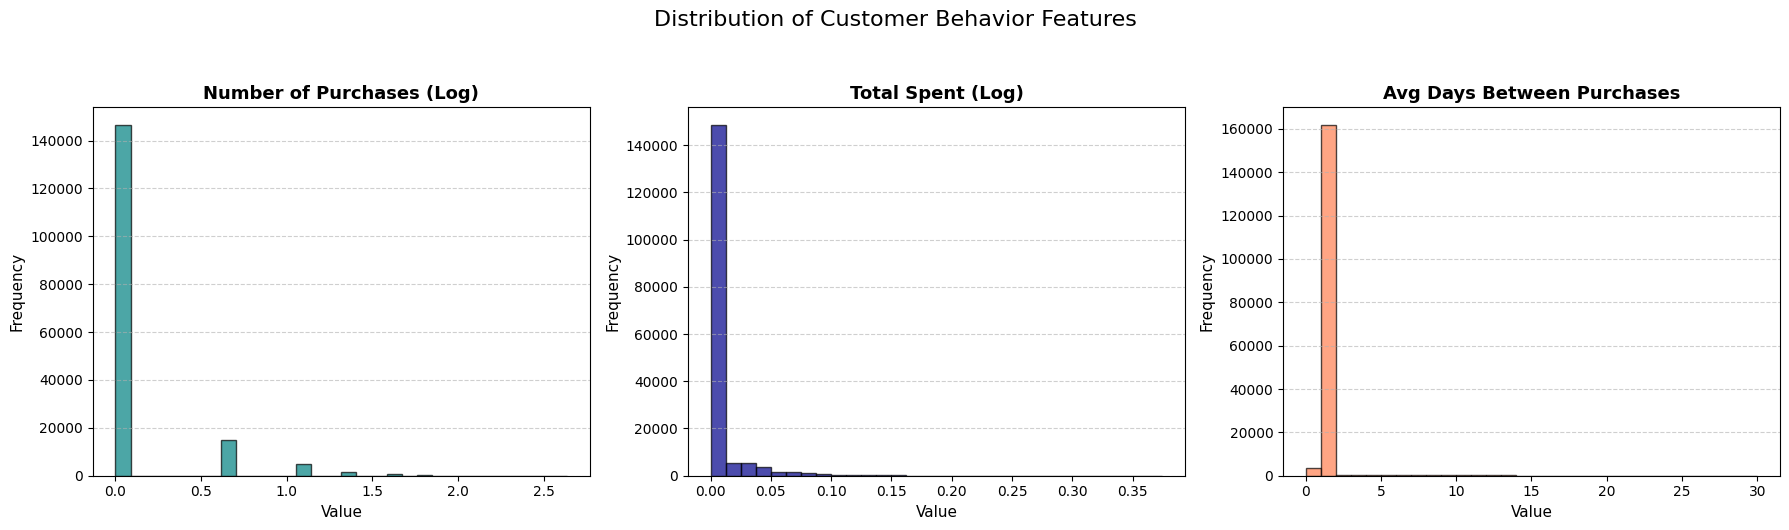

In [9]:
cols = ['log_num_purchases', 'log_total_spent', 'avg_days_between_purchases']
titles = ['Number of Purchases (Log)', 'Total Spent (Log)', 'Avg Days Between Purchases']
colors = ['teal', 'darkblue', 'coral']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3):
    axes[i].hist(X_train[cols[i]], bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Value", fontsize=11)
    axes[i].set_ylabel("Frequency", fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

fig.suptitle('Distribution of Customer Behavior Features', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Sales Distribution

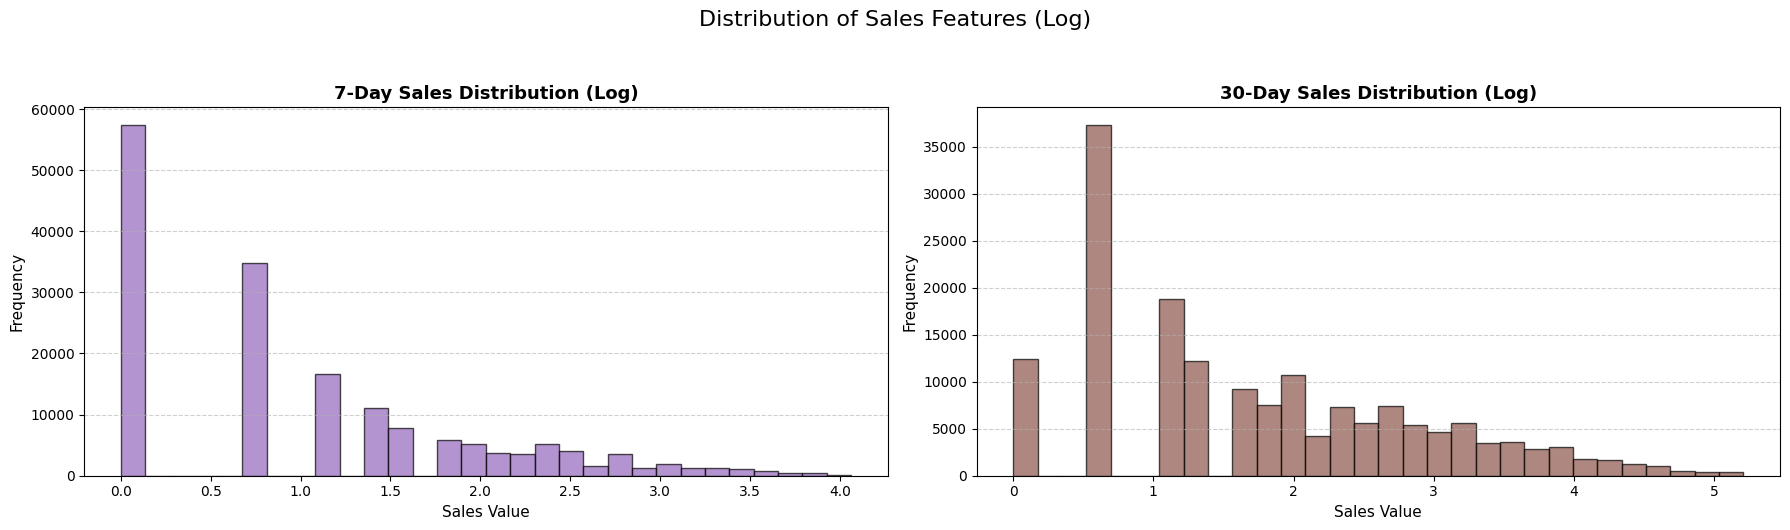

In [10]:
sales_cols = ['log_sales_last_7_days', 'log_sales_last_30_days']
titles = [ '7-Day Sales Distribution (Log)', '30-Day Sales Distribution (Log)']
colors = [ '#9467bd', '#8c564b']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for i in range(2):
    axes[i].hist(X_train[sales_cols[i]], bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Sales Value", fontsize=11)
    axes[i].set_ylabel("Frequency", fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

fig.suptitle('Distribution of Sales Features (Log)', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## Model building

Build a neural net model with variable number of hidden layers.

- num_features: number of features in dataset
- hidden_layer_sizes: variable array of nodes in hidden layers of neural net
- learning_rate: hyperparameter learning rate
- activation: activation function used within hidden layers
- optimizer: Adam or SGD optimizer

Uses sigmoid activation for the final layer. Reports accuracy.

In [11]:
class MajorityClassifier:  
    def fit(self, X, y):
        y_actual = self._y_actual(y)
        
        self.majority = y_actual.mode()[0]
        self.majority_probability = (y_actual == self.majority).mean()
        self.class_probabilities = y_actual.value_counts(normalize=True).sort_index()
        self.classes = self.class_probabilities.index.to_list()

    def predict(self, X):
        return np.full(len(X), self.majority)

    def evaluate(self, X, y):
        prediction = self.predict(X)
        actual = self._y_actual(y)
        accuracy = (prediction == actual).mean()
        return {'accuracy': accuracy}

    def log_loss(self, y):
        y_actual = self._y_actual(y)
        
        predicted_probabilities = np.tile(self.class_probabilities.values, (len(y), 1))
        
        y_one_hot = np.zeros((len(y), len(self.classes)))
        for i, val in enumerate(y_actual):
            class_idx = self.classes.index(val)
            y_one_hot[i, class_idx] = 1 
        
        log_p = np.log(np.clip(predicted_probabilities, 1e-15, 1))
        return -np.sum(y_one_hot * log_p) / len(y)
    
    def _y_actual(self, y):
        return y.iloc[:, 0] if isinstance(y, pd.DataFrame) else y

In [12]:
baseline = MajorityClassifier()
baseline.fit(X_train_scaled, y_train)

print(f"Baseline predictions: Always predict {baseline.majority}")
print(f"Training accuracy: {baseline.evaluate(X_train_scaled, y_train)['accuracy']:.4f}")
print(f"Training loss: {baseline.log_loss(y_train):.4f}")

print(f"Validation accuracy: {baseline.evaluate(X_val_scaled, y_val)['accuracy']:.4f}")
print(f"Validation loss: {baseline.log_loss(y_val):.4f}")

Baseline predictions: Always predict 0
Training accuracy: 0.5000
Training loss: 0.6931
Validation accuracy: 0.8333
Validation loss: 0.6931


In [13]:
def build_recommendation_model(num_features,
                                hidden_layer_sizes=[512],
                                learning_rate=0.001,
                                activation='relu',
                                optimizer="Adam"):
    tf.keras.backend.clear_session()
    tf.random.set_seed(67)

    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(num_features,)))
    for i, layer_units in enumerate(hidden_layer_sizes):
        layer = tf.keras.layers.Dense(
            units=layer_units,
            use_bias=True,
            activation=activation,
            kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
            bias_initializer=tf.initializers.RandomNormal(stddev=0.01)
        )
        model.add(layer)
        model.add(tf.keras.layers.Dropout(0.5))
    
    model.add(tf.keras.layers.Dense(
        units=1,
        use_bias=True,
        activation='sigmoid',
        kernel_initializer=tf.initializers.RandomNormal(stddev=0.01),
        bias_initializer=tf.initializers.RandomNormal(stddev=0.01)
        )
    )

    if optimizer == "SGD":
        keras_optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer == "Adam":
        keras_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        keras_optimizer = optimizer

    model.compile(
        loss=tf.keras.losses.BinaryCrossentropy(),
        optimizer=keras_optimizer,
        metrics=[
            tf.keras.metrics.AUC(name='auc_roc', curve='ROC'),
            tf.keras.metrics.AUC(name='pr_auc', curve='PR'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    
    return model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,305 (40.25 KB)

 Trainable params: 10,305 (40.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
10562/10562 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - auc_roc: 0.9739 - loss: 0.1989 - pr_auc: 0.9760 - precision: 0.9187 - recall: 0.8896 - val_auc_roc: 0.9750 - val_loss: 0.1939 - val_pr_auc: 0.9210 - val_precision: 0.6828 - val_recall: 0.8892
Epoch 2/10
10562/10562 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - auc_roc: 0.9768 - loss: 0.1874 - pr_auc: 0.9785 - precision: 0.9254 - recall: 0.8933 - val_auc_roc: 0.9751 - val_loss: 0.2002 - val_pr_auc: 0.9207 - val_precision: 0.6798 - val_recall: 0.8911
Epoch 3/10
10562/10562 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - auc_roc: 0.9770 - loss: 0.1865 - pr_auc: 0.9787 - precision: 0.9265 - recall: 0.8928 - val_auc_roc: 0.9753 - val_loss: 0.1856 - val_pr_auc: 0.9217 - val_precision: 0.6861 - val_recall: 0.8889
Epoch 4/10
10562/10562 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - auc_roc: 0.9773 - loss: 0.1857 - pr_auc: 0.9789 - precision: 0.9275 - recall: 0.8927 - val_auc_roc: 0.9755 - val_loss: 0.1915 - val_pr_auc: 0.9217 - val_precision: 0.6850 - val_recall: 0.8

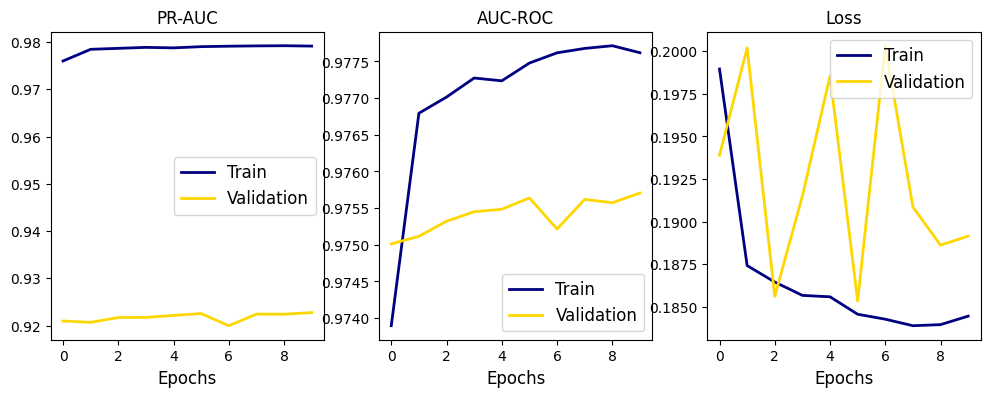

In [14]:

model = build_recommendation_model(X_train_scaled.shape[1],
                                    hidden_layer_sizes=[128,32],
                                    learning_rate=0.001,
                                    activation='relu',
                                    optimizer="Adam")
model.summary()

history = model.fit(X_train_scaled, y_train,
                    validation_data=(X_val_scaled, y_val),
                    epochs=10,
                    batch_size=16,
                    verbose=1)

history=history.history
fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history['pr_auc'], lw=2, color='navy')
plt.plot(history['val_pr_auc'], lw=2, color='gold')
plt.legend(['Train', 'Validation'], fontsize=12)
ax.set_xlabel('Epochs', size=12)
ax.set_title('PR-AUC', size=12)

ax = fig.add_subplot(1, 3, 2)
plt.plot(history['auc_roc'], lw=2, color='navy')
plt.plot(history['val_auc_roc'], lw=2, color='gold')
plt.legend(['Train', 'Validation'], fontsize=12)
ax.set_xlabel('Epochs', size=12)
ax.set_title('AUC-ROC', size=12)


ax = fig.add_subplot(1, 3, 3)
plt.plot(history['loss'], lw=2, color='navy')
plt.plot(history['val_loss'], lw=2, color='gold')
plt.legend(['Train', 'Validation'], fontsize=12)
ax.set_xlabel('Epochs', size=12)
ax.set_title('Loss', size=12)

plt.show()

## Test Data

In [15]:
test_loss, test_auc_roc, test_pr_auc, test_precision, test_recall = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"====== FINAL MODEL EVALUATION ======")
print(f"\nNeural Network Results:")
print(f"  Test Loss:      {test_loss:.4f}")
print(f"  Test AUC-ROC:   {test_auc_roc:.4f}")
print(f"  Test PR-AUC:    {test_pr_auc:.4f}")
print(f"  Test Precision: {test_precision:.4f}")
print(f"  Test Recall:    {test_recall:.4f}")

====== FINAL MODEL EVALUATION ======

Neural Network Results:
  Test Loss:      0.2349
  Test AUC-ROC:   0.9722
  Test PR-AUC:    0.9120
  Test Precision: 0.6267
  Test Recall:    0.9059


## Confusion Matrix

10211/10211 ━━━━━━━━━━━━━━━━━━━━ 2s 168us/step


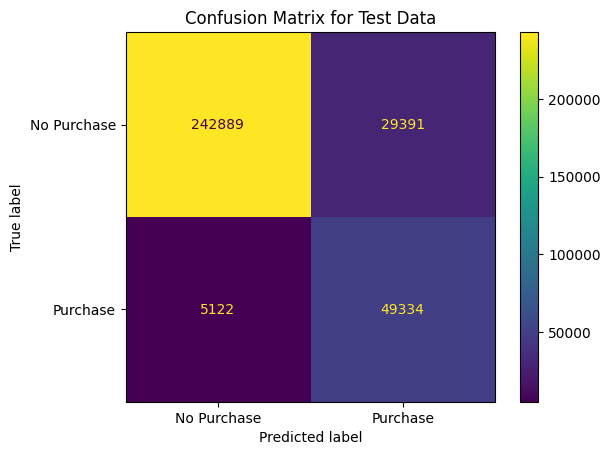

In [16]:
PURCHASE = "Purchase"
NO_PURCHASE = "No Purchase"
LABELS = [NO_PURCHASE, PURCHASE]

probability_threshold = 0.5

predictions = model.predict(x=X_test_scaled) > probability_threshold
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=LABELS)
disp.plot()
plt.title("Confusion Matrix for Test Data")
plt.show()

In [17]:
print("\nClassification Report:")
print(classification_report(y_test.values, predictions, target_names=LABELS))



Classification Report:
              precision    recall  f1-score   support

 No Purchase       0.98      0.89      0.93    272280
    Purchase       0.63      0.91      0.74     54456

    accuracy                           0.89    326736
   macro avg       0.80      0.90      0.84    326736
weighted avg       0.92      0.89      0.90    326736



In [18]:
true_neg, false_pos, false_neg, true_pos = cm.ravel()
precision = true_pos / (true_pos + false_pos)
recall = true_pos / (true_pos + false_neg)


print(f"  True Negatives:  {true_neg:,} (correctly predicted no purchase)")
print(f"  False Positives: {false_pos:,} (predicted purchase, but didn't buy)")
print(f"  False Negatives: {false_neg:,} (predicted no purchase, but did buy)")
print(f"  True Positives:  {true_pos:,} (correctly predicted purchase)")
print(f"\n")
print(f"  Precision: {precision:.2%} (of {(true_pos + false_pos):,} predicted purchases, how many were correct)")
print(f"  Recall:    {recall:.2%} (of {(true_pos + false_neg):,} actual purchases, how many did we catch)")

  True Negatives:  242,889 (correctly predicted no purchase)
  False Positives: 29,391 (predicted purchase, but didn't buy)
  False Negatives: 5,122 (predicted no purchase, but did buy)
  True Positives:  49,334 (correctly predicted purchase)


  Precision: 62.67% (of 78,725 predicted purchases, how many were correct)
  Recall:    90.59% (of 54,456 actual purchases, how many did we catch)
